# Unemployment Analysis and Prediction in India and Pakistan

## Importing Libraries

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Lasso
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
from joblib import dump
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
import pickle

## Data Collection and Preprocessing

### Importing Dataset

In [78]:
unemploy_sex_age_edu = 'data/raw/unemployment_sex_age_edu.csv'
unemploy_sex_age_marital = 'data/raw/unemployment_sex_age_martial.csv'
unemploy_sex_age_region = 'data/raw/unemployment_sex_age_region.csv'
population = 'data/raw/population.csv'
inflation = 'data/raw/inflation.csv'
gdp = 'data/raw/gdp.csv'
unemployment_rate = 'data/raw/unemployment_rate.csv'
labor_force_rate = 'data/raw/labour_force_participation.csv'
employment_sector = 'data/raw/employment_by_sector.csv'

unemploy_sex_age_edu_df = pd.read_csv(unemploy_sex_age_edu)
unemploy_sex_age_marital_df = pd.read_csv(unemploy_sex_age_marital)
unemploy_sex_age_region_df = pd.read_csv(unemploy_sex_age_region)
population_df = pd.read_csv(population)
inflation_df = pd.read_csv(inflation)
gdp_df = pd.read_csv(gdp)
unemployment_rate_df = pd.read_csv(unemployment_rate)
labor_force_rate_df = pd.read_csv(labor_force_rate)
employment_sector_df = pd.read_csv(employment_sector)

### Dropping unnecessary columns

In [79]:
unemploy_sex_age_edu_df = unemploy_sex_age_edu_df.drop(['source.label', 'indicator.label', 'obs_status.label', 'note_classif.label', 'note_indicator.label', 'note_source.label'], axis=1)
unemploy_sex_age_marital_df = unemploy_sex_age_marital_df.drop(['source.label', 'indicator.label', 'obs_status.label', 'note_classif.label', 'note_indicator.label', 'note_source.label'], axis=1)
unemploy_sex_age_region_df = unemploy_sex_age_region_df.drop(['source.label', 'indicator.label', 'obs_status.label', 'note_classif.label', 'note_indicator.label', 'note_source.label'], axis=1)

In [80]:
countries = ['India', 'Pakistan']

def extract_year_country(df):
    df = df[df['Country Name'].isin(countries)]
    years = [str(year) for year in range(2005,2024)]
    df = df.loc[:,['Country Name']+years]
    return df

population_df = extract_year_country(population_df)
inflation_df = extract_year_country(inflation_df)
gdp_df = extract_year_country(gdp_df)
labor_force_rate_df = extract_year_country(labor_force_rate_df)

In [81]:
sector_list = ['Agriculture, total', 'Industry, total', 'Services, total']
employment_sector_df = employment_sector_df[employment_sector_df['Disaggregation'].isin(sector_list)]
employment_sector_df[['sector', 'total']] = employment_sector_df['Disaggregation'].str.split(', ', expand=True)
employment_sector_df = employment_sector_df[employment_sector_df['Country Name'].isin(countries)]
years_range = np.arange(2005,2023)
employment_sector_df = employment_sector_df[employment_sector_df['Year'].isin(years_range)]
employment_sector_df = employment_sector_df[['Country Name', 'Year', 'Value', 'sector']]

### Renaming Columns

In [82]:
unemploy_sex_age_edu_df.rename(columns={
    'ref_area.label': 'country',
    'sex.label': 'gender',
    'classif1.label': 'age_bracket',
    'classif2.label': 'education',
    'obs_value': 'value'
}, inplace=True)

unemploy_sex_age_marital_df.rename(
    columns={
        'ref_area.label': 'country',
        'sex.label': 'gender',
        'classif1.label': 'age_bracket',
        'classif2.label': 'marital_status',
        'obs_value': 'value'
    }, inplace=True
)

unemploy_sex_age_region_df.rename(
    columns={
        'ref_area.label': 'country',
        'sex.label': 'gender',
        'classif1.label': 'age_bracket',
        'classif2.label': 'region',
        'obs_value': 'value'
    }, inplace=True
)

labor_force_rate_df.rename(
    columns={
        'ref_area.label': 'country',
        'sex.label': 'gender',
        'classif1.label': 'age_bracket',
        'obs_value': 'rate'
    }, inplace=True
)

def rename_country(df):
    return df.rename(columns={'Country Name':'country'})

population_df = rename_country(population_df)
inflation_df = rename_country(inflation_df)
gdp_df = rename_country(gdp_df)
unemployment_rate_df = rename_country(unemployment_rate_df)
labor_force_rate_df = rename_country(labor_force_rate_df)
employment_sector_df = rename_country(employment_sector_df)

### Handling rows and null values

#### Unemployment (Gender, Age, Education) Dataset

In [83]:
unemploy_sex_age_edu_df['gender'] = unemploy_sex_age_edu_df['gender'].str.replace('Sex: ','')
unemploy_sex_age_marital_df['gender'] = unemploy_sex_age_marital_df['gender'].str.replace('Sex: ', '')
unemploy_sex_age_region_df['gender'] = unemploy_sex_age_region_df['gender'].str.replace('Sex: ', '')

unemploy_sex_age_edu_df['age_bracket'] = unemploy_sex_age_edu_df['age_bracket'].str.replace('Age (Aggregate bands): ','')
unemploy_sex_age_marital_df['age_bracket'] = unemploy_sex_age_marital_df['age_bracket'].str.replace('Age (Aggregate bands): ','')
unemploy_sex_age_region_df['age_bracket'] = unemploy_sex_age_region_df['age_bracket'].str.replace('Age (Aggregate bands): ','')

unemploy_sex_age_edu_df['education'] = unemploy_sex_age_edu_df['education'].str.replace('Education (Aggregate levels): ','')

unemploy_sex_age_marital_df['marital_status'] = unemploy_sex_age_marital_df['marital_status'].str.replace('Marital status (Detailed): ',  '')

unemploy_sex_age_region_df['region'] = unemploy_sex_age_region_df['region'].str.replace('Area type: ',  '')

In [84]:
education_to_replace = {
    'Less than basic': 'Below High School',
    'Basic': 'High School', 
    'Intermediate': 'Bachelor\'s',
    'Advanced': 'Master\'s or Higher',
    'Level not stated': 'Not Stated'
}

unemploy_sex_age_edu_df['education'] = unemploy_sex_age_edu_df['education'].replace(education_to_replace)

##### Null Values Handle

In [85]:
unemploy_sex_age_edu_df['value'] = unemploy_sex_age_edu_df.groupby(['age_bracket', 'education'])['value'].transform(lambda x: x.fillna(x.mean()))
unemploy_sex_age_edu_df_value_global_mean = unemploy_sex_age_edu_df['value'].mean()
unemploy_sex_age_edu_df['value'] = unemploy_sex_age_edu_df['value'].fillna(unemploy_sex_age_edu_df_value_global_mean)
unemploy_sex_age_edu_df['value'] = round(unemploy_sex_age_edu_df['value'])

unemploy_sex_age_marital_df['value'] = unemploy_sex_age_marital_df.groupby(['age_bracket', 'marital_status'])['value'].transform(lambda x: x.fillna(x.mean()))
unemploy_sex_age_marital_df_value_global_mean = unemploy_sex_age_marital_df['value'].mean()
unemploy_sex_age_marital_df['value'] = unemploy_sex_age_marital_df['value'].fillna(unemploy_sex_age_marital_df_value_global_mean)
unemploy_sex_age_marital_df['value'] = round(unemploy_sex_age_marital_df['value'])

unemploy_sex_age_region_df['value'] = unemploy_sex_age_region_df.groupby(['age_bracket', 'region'])['value'].transform(lambda x: x.fillna(x.mean()))
unemploy_sex_age_region_df_value_global_mean = unemploy_sex_age_region_df['value'].mean()
unemploy_sex_age_region_df['value'] = unemploy_sex_age_region_df['value'].fillna(unemploy_sex_age_region_df_value_global_mean)
unemploy_sex_age_region_df['value'] = round(unemploy_sex_age_region_df['value'])

##### Convert Data Types

In [86]:
unemploy_sex_age_edu_df['value'] = unemploy_sex_age_edu_df['value'].astype('int')
unemploy_sex_age_edu_df['gender'] = unemploy_sex_age_edu_df['gender'].astype('category')
unemploy_sex_age_edu_df['age_bracket'] = unemploy_sex_age_edu_df['age_bracket'].astype('category')
unemploy_sex_age_edu_df['education'] = unemploy_sex_age_edu_df['education'].astype('category')
unemploy_sex_age_edu_df['time'] =  pd.PeriodIndex(unemploy_sex_age_edu_df['time'], freq='Q')
unemploy_sex_age_edu_df['time'] = unemploy_sex_age_edu_df['time'].dt.to_timestamp()

unemploy_sex_age_marital_df['value'] = unemploy_sex_age_marital_df['value'].astype('int')
unemploy_sex_age_marital_df['gender'] = unemploy_sex_age_marital_df['gender'].astype('category')
unemploy_sex_age_marital_df['age_bracket'] = unemploy_sex_age_marital_df['age_bracket'].astype('category')
unemploy_sex_age_marital_df['marital_status'] = unemploy_sex_age_marital_df['marital_status'].astype('category')
unemploy_sex_age_marital_df['time'] =  pd.PeriodIndex(unemploy_sex_age_marital_df['time'], freq='Q')
unemploy_sex_age_marital_df['time'] = unemploy_sex_age_marital_df['time'].dt.to_timestamp()

unemploy_sex_age_region_df['value'] = unemploy_sex_age_region_df['value'].astype('int')
unemploy_sex_age_region_df['gender'] = unemploy_sex_age_region_df['gender'].astype('category')
unemploy_sex_age_region_df['age_bracket'] = unemploy_sex_age_region_df['age_bracket'].astype('category')
unemploy_sex_age_region_df['region'] = unemploy_sex_age_region_df['region'].astype('category')
unemploy_sex_age_region_df['time'] =  pd.PeriodIndex(unemploy_sex_age_region_df['time'], freq='Q')
unemploy_sex_age_region_df['time'] = unemploy_sex_age_region_df['time'].dt.to_timestamp()

##### Wide to Long data

In [87]:
def wide2Long(df, value_name):
    df = df.melt(id_vars='country', value_name=value_name, var_name='year')
    df = df[df['year'] >= '2005']
    df['year'] = pd.to_datetime(df['year'], format='%Y')
    return df

population_df = wide2Long(population_df, 'count')
gdp_df = wide2Long(gdp_df, 'rate')
inflation_df = wide2Long(inflation_df, 'rate')
unemployment_rate_df = wide2Long(unemployment_rate_df, 'rate')
labor_force_rate_df =  wide2Long(labor_force_rate_df, 'count')

#### Export clean dataframes

In [88]:
unemployment_rate_df.to_csv('data/clean_data/unemployment_rate.csv')

## EDA

In [89]:
custom_palette = {
    'India': 'orange',
    'Pakistan': 'green',
}

custome_order = ['India', 'Pakistan']

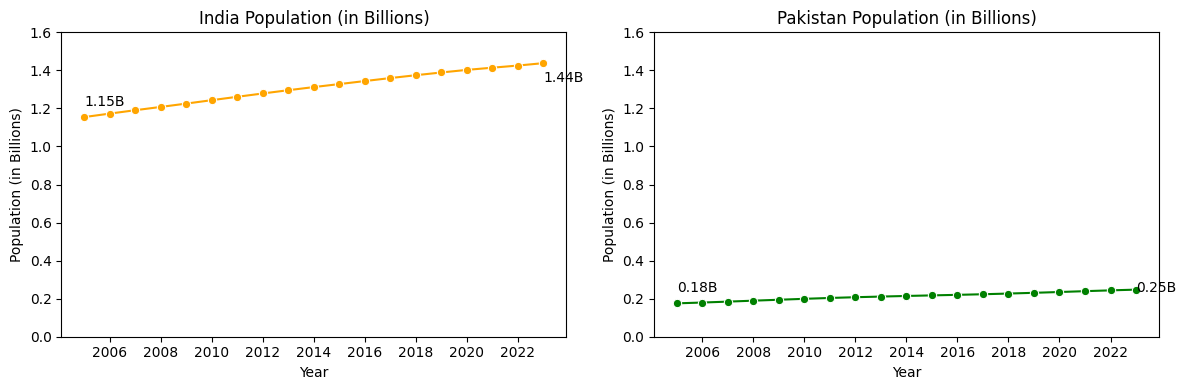

In [90]:
population_df_india = population_df[population_df['country'] == 'India']
population_df_pakistan = population_df[population_df['country'] == 'Pakistan']

population_df_india.loc[:, 'count'] = population_df_india['count']/1000000000
population_df_pakistan.loc[:, 'count'] = population_df_pakistan['count']/1000000000

fig, axes = plt.subplots(1,2,figsize=(12,4))

sns.lineplot(data=population_df_india, x='year', y='count', ax=axes[0], marker='o', color='orange')
axes[0].set_title('India Population (in Billions)')
axes[0].set_ylabel('Population (in Billions)')
axes[0].set_xlabel('Year')
axes[0].set_ylim(0, 1.6)

first_india = population_df_india.iloc[0]
last_india = population_df_india.iloc[-1]
axes[0].annotate(f'{first_india["count"]:.2f}B', xy=(first_india['year'], first_india['count']+0.06))
axes[0].annotate(f'{last_india["count"]:.2f}B', xy=(last_india['year'], last_india['count']-0.1))

sns.lineplot(data=population_df_pakistan, x='year', y='count', ax=axes[1], marker='o', color='green')
axes[1].set_title('Pakistan Population (in Billions)')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Population (in Billions)')
axes[1].set_ylim(0, 1.6)

first_pakistan = population_df_pakistan.iloc[0]
last_pakistan = population_df_pakistan.iloc[-1]
axes[1].annotate(f'{first_pakistan["count"]:.2f}B', xy=(first_pakistan['year'], first_pakistan['count']+0.06))
axes[1].annotate(f'{last_pakistan["count"]:.2f}B', xy=(last_pakistan['year'], first_pakistan['count']+0.06))

plt.tight_layout()
plt.show()

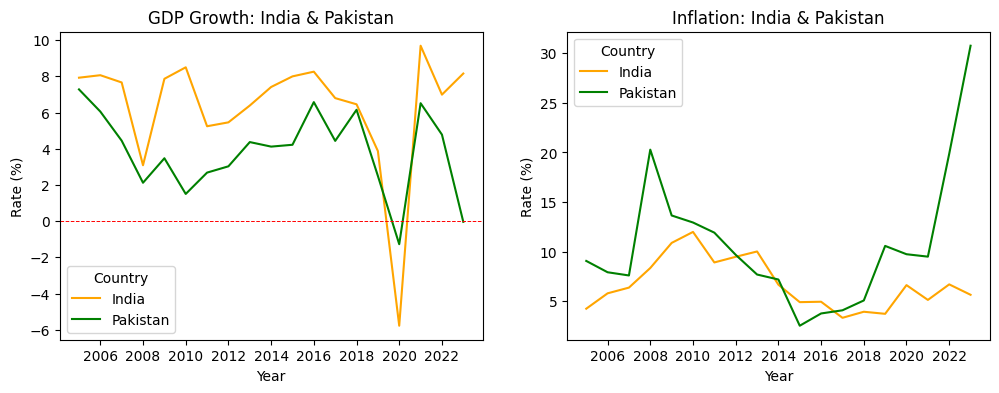

In [91]:
fig, axes = plt.subplots(1,2,figsize=(12,4))

sns.lineplot(data=gdp_df, x='year', y='rate', hue='country', palette=custom_palette, ax=axes[0])
axes[0].legend(title='Country')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Rate (%)')
axes[0].set_title('GDP Growth: India & Pakistan')
axes[0].axhline(0, color='red', linestyle='--', linewidth=0.7)

sns.lineplot(data=inflation_df, x='year', y='rate', hue='country', palette=custom_palette, ax=axes[1])
axes[1].legend(title='Country')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Rate (%)')
axes[1].set_title('Inflation: India & Pakistan')

plt.show()

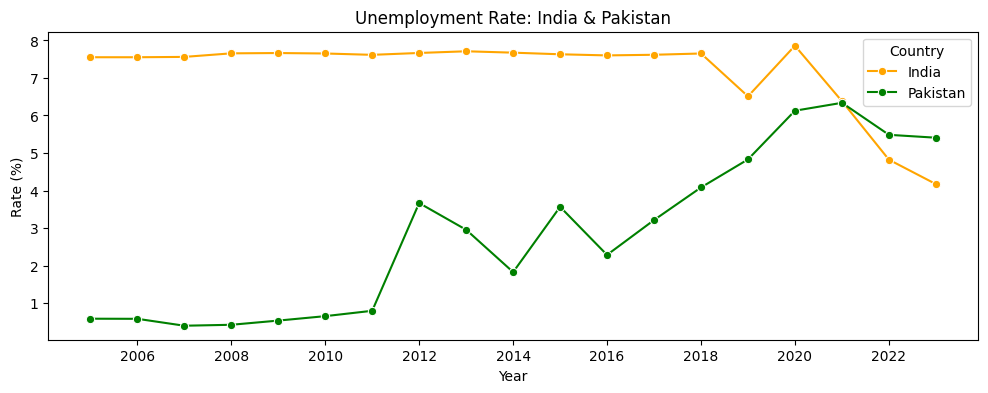

In [92]:
plt.figure(figsize=(12,4))
sns.lineplot(data=unemployment_rate_df, x='year', y='rate', hue='country', marker='o', palette=custom_palette, hue_order=custome_order) 
plt.title('Unemployment Rate: India & Pakistan')
plt.xlabel('Year')
plt.ylabel('Rate (%)')
plt.legend(title='Country')

plt.show()

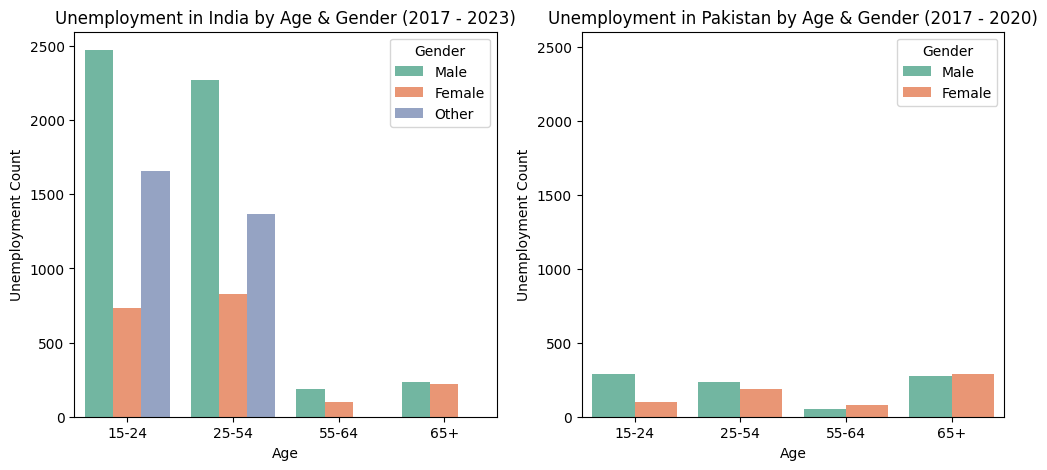

In [93]:
custom_order = ['Male', 'Female', 'Other']
custom_order2 = ['Male', 'Female']
unemploy_sex_age_edu_df_india = unemploy_sex_age_edu_df[unemploy_sex_age_edu_df['country'] == 'India']
unemploy_sex_age_edu_df_india = unemploy_sex_age_edu_df_india.groupby(['time','age_bracket', 'gender'], observed=True)['value'].agg(['mean'])
unemploy_sex_age_edu_df_india = unemploy_sex_age_edu_df_india.reset_index()
unemploy_sex_age_edu_df_pakistan = unemploy_sex_age_edu_df[unemploy_sex_age_edu_df['country'] == 'Pakistan']
unemploy_sex_age_edu_df_pakistan = unemploy_sex_age_edu_df_pakistan.groupby(['time','age_bracket', 'gender'], observed=True)['value'].agg(['mean'])
unemploy_sex_age_edu_df_pakistan = unemploy_sex_age_edu_df_pakistan.reset_index()

fig, axes = plt.subplots(1,2, figsize=(12,5))

sns.barplot(data=unemploy_sex_age_edu_df_india, x='age_bracket', y='mean', hue='gender', errorbar=None, hue_order=custom_order, palette="Set2", ax=axes[0])
axes[0].legend(title='Gender')
axes[0].set_title('Unemployment in India by Age & Gender (2017 - 2023)')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Unemployment Count')

sns.barplot(data=unemploy_sex_age_edu_df_pakistan, x='age_bracket', y='mean', hue='gender', errorbar=None, hue_order=custom_order2, palette="Set2", ax=axes[1])
axes[1].legend(title='Gender')
axes[1].set_title('Unemployment in Pakistan by Age & Gender (2017 - 2020)')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Unemployment Count')
axes[1].set_ylim(0, 2600)
plt.show()

In [94]:
unemploy_sex_age_edu_df_india.to_csv('data/clean_data/unemploy_sex_age_edu_india.csv')
unemploy_sex_age_edu_df_pakistan.to_csv('data/clean_data/unemploy_sex_age_edu_pakistan.csv')

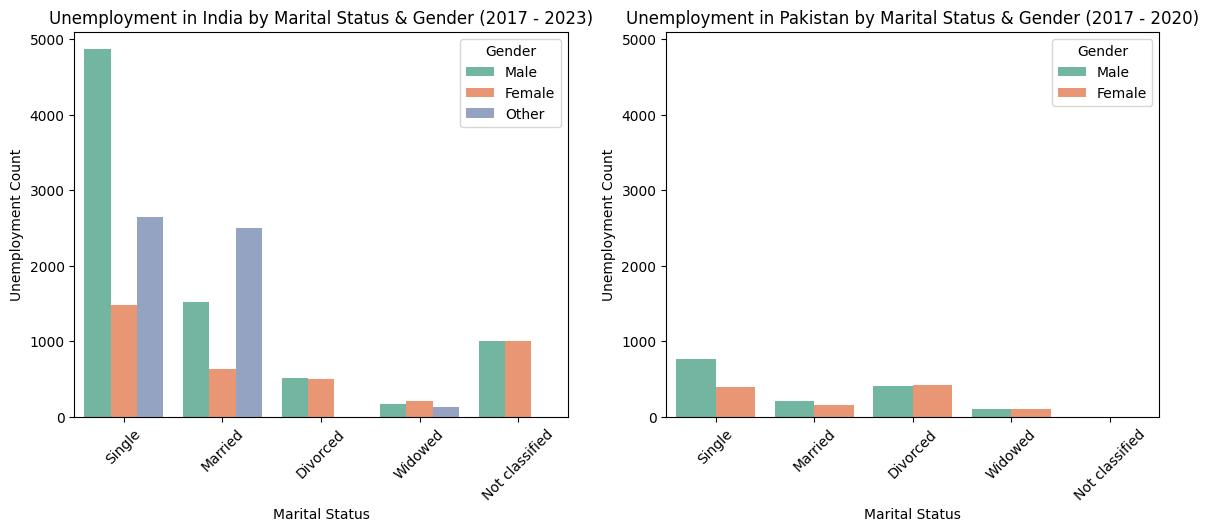

In [95]:
label_order = ['Single', 'Married', 'Divorced', 'Widowed', 'Not classified']
unemploy_sex_age_marital_df_india = unemploy_sex_age_marital_df[unemploy_sex_age_marital_df['country'] == 'India']
unemploy_sex_age_marital_df_india = unemploy_sex_age_marital_df_india.groupby(['time','marital_status', 'gender'], observed=True)['value'].agg(['mean'])
unemploy_sex_age_marital_df_india = unemploy_sex_age_marital_df_india.reset_index()
unemploy_sex_age_marital_df_pakistan = unemploy_sex_age_marital_df[unemploy_sex_age_marital_df['country'] == 'Pakistan']
unemploy_sex_age_marital_df_pakistan = unemploy_sex_age_marital_df_pakistan.groupby(['time','marital_status', 'gender'], observed=True)['value'].agg(['mean'])
unemploy_sex_age_marital_df_pakistan = unemploy_sex_age_marital_df_pakistan.reset_index()

fig, axes = plt.subplots(1,2, figsize=(14,5))

sns.barplot(data=unemploy_sex_age_marital_df_india, x='marital_status', y='mean', hue='gender', errorbar=None, hue_order=custom_order, palette="Set2", ax=axes[0], order=label_order)
axes[0].legend(title='Gender')
axes[0].set_title('Unemployment in India by Marital Status & Gender (2017 - 2023)')
axes[0].set_xlabel('Marital Status')
axes[0].set_ylabel('Unemployment Count')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylim(0, 5100)

sns.barplot(data=unemploy_sex_age_marital_df_pakistan, x='marital_status', y='mean', hue='gender', errorbar=None, palette="Set2",hue_order=custom_order2, ax=axes[1], order=label_order)
axes[1].legend(title='Gender')
axes[1].set_title('Unemployment in Pakistan by Marital Status & Gender (2017 - 2020)')
axes[1].set_xlabel('Marital Status')
axes[1].set_ylabel('Unemployment Count')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylim(0, 5100)
plt.show()

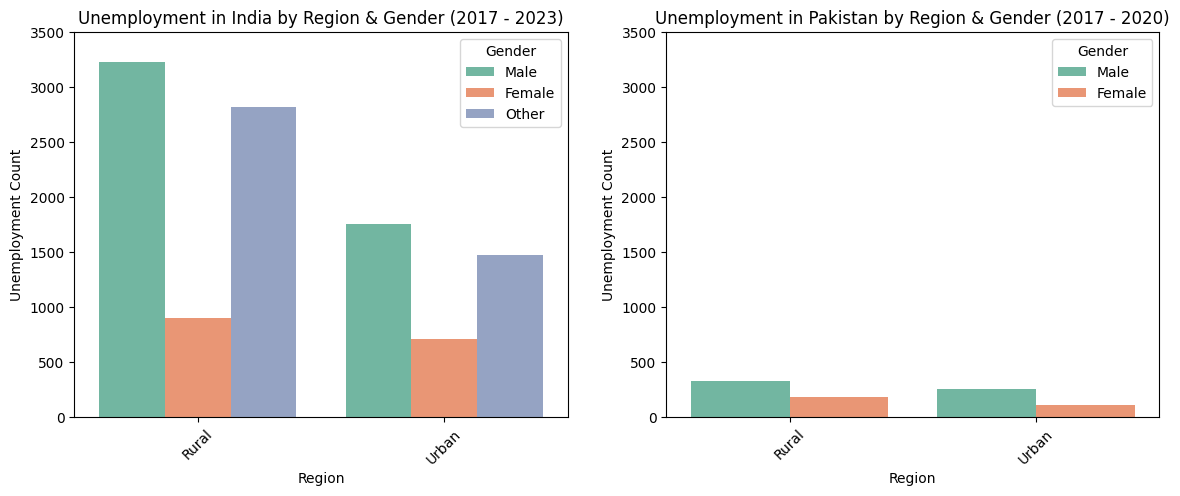

In [96]:
unemploy_sex_age_region_df_india = unemploy_sex_age_region_df[unemploy_sex_age_region_df['country'] == 'India']
unemploy_sex_age_region_df_india = unemploy_sex_age_region_df_india.groupby(['time','region', 'gender'], observed=True)['value'].agg(['mean'])
unemploy_sex_age_region_df_india = unemploy_sex_age_region_df_india.reset_index()
unemploy_sex_age_region_df_pakistan = unemploy_sex_age_region_df[unemploy_sex_age_region_df['country'] == 'Pakistan']
unemploy_sex_age_region_df_pakistan = unemploy_sex_age_region_df_pakistan.groupby(['time','region', 'gender'], observed=True)['value'].agg(['mean'])
unemploy_sex_age_region_df_pakistan = unemploy_sex_age_region_df_pakistan.reset_index()

fig, axes = plt.subplots(1,2, figsize=(14,5))

sns.barplot(data=unemploy_sex_age_region_df_india, x='region', y='mean', hue='gender', errorbar=None, hue_order=custom_order, palette="Set2", ax=axes[0])
axes[0].legend(title='Gender')
axes[0].set_title('Unemployment in India by Region & Gender (2017 - 2023)')
axes[0].set_xlabel('Region')
axes[0].set_ylabel('Unemployment Count')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylim(0,3500)

sns.barplot(data=unemploy_sex_age_region_df_pakistan, x='region', y='mean', hue='gender', errorbar=None, palette="Set2",hue_order=custom_order2, ax=axes[1])
axes[1].legend(title='Gender')
axes[1].set_title('Unemployment in Pakistan by Region & Gender (2017 - 2020)')
axes[1].set_xlabel('Region')
axes[1].set_ylabel('Unemployment Count')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylim(0,3500)
plt.show()

In [97]:
unemploy_sex_age_region_df_india.to_csv('data/clean_data/unemploy_sex_age_region_india.csv')
unemploy_sex_age_region_df_pakistan.to_csv('data/clean_data/unemploy_sex_age_region_pakistan.csv')

## Model Building Preparation

### Merging the dataframe

In [72]:
population_df.rename(columns={'count':'population_count'}, inplace=True)
inflation_df.rename(columns={'rate':'inflation_rate'}, inplace=True)
gdp_df.rename(columns={'rate':'gdp_rate'}, inplace=True)
labor_force_rate_df.rename(columns={'count':'labor_force_count'}, inplace=True)
employment_sector_df.rename(columns={'Year':'year', 'Value': 'employment_sector_value'}, inplace=True)
employment_sector_df['year'] = pd.to_datetime(employment_sector_df['year'], format='%Y')

In [73]:
merged_df = population_df.merge(inflation_df, on=['country', 'year'], how='outer').merge(gdp_df, on=['country', 'year'], how='outer').merge(labor_force_rate_df, on=['country', 'year'], how='outer').merge(employment_sector_df, on=['country', 'year'], how='outer').merge(unemployment_rate_df, on=['country', 'year'], how='outer')
merged_df.dropna(inplace=True)

In [74]:
avg_agriculture = merged_df[merged_df.sector == 'Agriculture']['employment_sector_value'].mean()
avg_industry = merged_df[merged_df.sector == 'Industry']['employment_sector_value'].mean()
avg_service = merged_df[merged_df.sector == 'Services']['employment_sector_value'].mean()

### Categorical Encoding

In [75]:
merged_df = pd.get_dummies(data=merged_df ,columns=['country', 'sector'], drop_first=True)
merged_df['year'] = merged_df['year'].dt.year.astype('int')

In [76]:
merged_df.to_csv('data/clean_data/merge_df.csv')

## Model Training

In [23]:
X = merged_df.drop(['rate'], axis=1)
y = merged_df['rate'].values.ravel()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1111)

### Random Forest

In [24]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=1111)
rf_model.fit(X_train, y_train)

y_rf_train_pred = rf_model.predict(X_train)
y_rf_test_pred = rf_model.predict(X_test)

rf_train_rmse = np.sqrt(mean_squared_error(y_train, y_rf_train_pred))
rf_train_r2 = r2_score(y_train, y_rf_train_pred)

rf_test_rmse =  np.sqrt(mean_squared_error(y_test, y_rf_test_pred))
rf_test_r2 = r2_score(y_test, y_rf_test_pred)

In [25]:
print(f'Training set Root Mean Squared Error: {rf_train_rmse}')
print(f'Training set R-squared: {rf_train_r2}')

print(f'Test set Root Mean Squared Error: {rf_test_rmse}')
print(f'Test set R-squared: {rf_test_r2}')

Training set Root Mean Squared Error: 0.12736167638968418
Training set R-squared: 0.9977603288970263
Test set Root Mean Squared Error: 0.3184357953125926
Test set R-squared: 0.9870151681042902


#### Hyperparameter Tuning

In [ ]:
param_dist = {
    'n_estimators': [50, 70, 100, 150], 
    'max_depth': [5, 10, 15], 
    'max_features': ['sqrt', 'log2', 0.7 , 0.5], 
    'min_samples_split': [3, 4, 5], 
    'min_samples_leaf': [3, 4, 5] 
}


rf_random_search = RandomizedSearchCV(estimator=rf_model, n_iter=20, param_distributions=param_dist, scoring='neg_root_mean_squared_error', cv=3, n_jobs=2, random_state=1111)
rf_random_search.fit(X_train, y_train)
print(rf_random_search.best_params_)

In [ ]:
best_model = rf_random_search.best_estimator_
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

rf_train_rmse =  np.sqrt(mean_squared_error(y_train, y_train_pred))
rf_train_r2 = r2_score(y_train, y_train_pred)

rf_test_rmse =   np.sqrt(mean_squared_error(y_test, y_test_pred))
rf_test_r2 = r2_score(y_test, y_test_pred)

print('For Training Dataset')
print('RMSE ', rf_train_rmse)
print("R2 Score:", rf_train_r2)
print("")
print('For Testing Dataset')
print('RMSE ', rf_test_rmse)
print("R2 Score:", rf_test_r2)

For Training Dataset
RMSE  0.32330407029632113
R2 Score: 0.9855679156808855

For Testing Dataset
RMSE  0.33846103039232045
R2 Score: 0.9853306822965672


### XGBoost

In [ ]:
xgb_model = XGBRegressor(n_estimators=100, random_state=1111)
xgb_model.fit(X_train, y_train)

y_train_pred = xgb_model.predict(X_train)
y_test_pred = xgb_model.predict(X_test)

xgb_train_rmse =  np.sqrt(mean_squared_error(y_train, y_train_pred))
xgb_train_r2 = r2_score(y_train, y_train_pred)

xgb_test_rmse =   np.sqrt(mean_squared_error(y_test, y_test_pred))
xgb_test_r2 = r2_score(y_test, y_test_pred)

print('For Training Dataset')
print('RMSE ', xgb_train_rmse)
print("R2 Score:", xgb_train_r2)
print("")
print('For Testing Dataset')
print('RMSE ', xgb_test_rmse)
print("R2 Score:", xgb_test_r2)

For Training Dataset
RMSE  0.0003708728345210372
R2 Score: 0.9999999810086097

For Testing Dataset
RMSE  0.00038698367038169127
R2 Score: 0.9999999808231245


#### Hyperparameter Tuning

In [ ]:
param_dist = {
    'n_estimators': [200, 300],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [4, 6, 8],
    'reg_alpha': [1, 3, 5],
    'reg_lambda': [7, 10]
}

xgb_random_search = RandomizedSearchCV(estimator=xgb_model, param_distributions=param_dist, n_iter=30, scoring='neg_mean_absolute_error', cv=3, n_jobs=2, random_state=1111)
xgb_random_search.fit(X_train, y_train)
xgb_random_search.best_params_

{'reg_lambda': 7,
 'reg_alpha': 1,
 'n_estimators': 300,
 'max_depth': 8,
 'learning_rate': 0.2}

In [ ]:
best_model = xgb_random_search.best_estimator_
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

xgb_train_rmse = np.sqrt(mean_squared_error(y_train,y_train_pred))
xgb_train_r2 = r2_score(y_train, y_train_pred)

xgb_test_rmse =  np.sqrt(mean_squared_error(y_test,y_test_pred))
xgb_test_r2 = r2_score(y_test, y_test_pred)

print('For Training Dataset')
print('RMSE ', xgb_train_rmse)
print("R2 Score:", xgb_train_r2)
print("")
print('For Testing Dataset')
print('RMSE ', xgb_test_rmse)
print("R2 Score:", xgb_test_r2)

For Training Dataset
RMSE  0.10363953593796019
R2 Score: 0.9985169437194289

For Testing Dataset
RMSE  0.10710404461015811
R2 Score: 0.998531059133913


#### Export model as pickle file

In [ ]:
avg_sector_values = {
    'Agriculture': avg_agriculture,
    'Industry': avg_industry,
    'Services': avg_service
}
with open('data/model/avg_sector_values.pkl', 'wb') as f:
    pickle.dump(avg_sector_values, f)

In [ ]:
best_model.save_model('data/model/unemployment_model_xgb.json') 

## Preparing models for prediction in Dashbaord

In [ ]:
def extract_year_country2(df):
    df = df[df['Country Name'].isin(countries)]
    years = [str(year) for year in range(1980,2024)]
    df = df.loc[:,['Country Name']+years]
    return df

def wide2Long2(df, value_name):
    df = df.melt(id_vars='country', value_name=value_name, var_name='year')
    df = df[df['year'] >= '1980']
    df['year'] = pd.to_datetime(df['year'], format='%Y')
    return df

future_years = range(2024, 2031) 

### Population Prediction

In [ ]:
population_df = pd.read_csv(population)

population_df = extract_year_country2(population_df)
population_df = rename_country(population_df)
population_df = wide2Long2(population_df, 'count')

In [ ]:
population_df['year_num'] = pd.to_datetime(population_df['year']).dt.year
population_prediction = {}
for country in countries:
    prediction_data = {}
    population_country_data = population_df[population_df['country'] == country]
    
    X = population_country_data['year_num'].values.reshape(-1, 1)
    y = population_country_data['count'].values
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1111)
    
    model = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    print(f"\nMetrics for {country}:")
    print(f"R² Score: {r2:.4f}")
    print(f"RMSE: {rmse:.2f}")
    
    future_X = np.array(future_years).reshape(-1, 1)
    future_predictions = model.predict(future_X)

    for year, pred in zip(future_years, future_predictions):
        prediction_data[year] = pred
    population_prediction[country] = prediction_data


Metrics for India:
R² Score: 0.9995
RMSE: 5077227.23

Metrics for Pakistan:
R² Score: 0.9994
RMSE: 1210060.12


### GDP Prediction

In [ ]:
gdp_df = pd.read_csv(gdp)

gdp_df = extract_year_country2(gdp_df)
gdp_df = rename_country(gdp_df)
gdp_df = wide2Long2(gdp_df, 'rate')

In [ ]:
df = gdp_df.copy()
gdp_prediction = {}

df["year_num"] = pd.to_datetime(df["year"]).dt.year
df["gdp_change"] = df["rate"].diff()
df["moving_avg"] = df["rate"].rolling(window=3, min_periods=1).mean()
df["prev2_year_gdp"] = df["rate"].shift(2)
df["prev_year_gdp"] = df["rate"].shift(1)
df.dropna(inplace=True)

features = ["year_num", "moving_avg", "gdp_change"]
target = "rate"

for country in countries:
    prediction_data = {}
    gdp_country_data = df[df['country'] == country]
    X = gdp_country_data[features]
    y = gdp_country_data[target]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model = Lasso(alpha=0.1)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    print(f"Metrics for {country}:")
    print(f"R² Score: {r2:.4f}")
    print(f"RMSE: {rmse:.2f}\n")  

    last_moving_avg = gdp_country_data["moving_avg"].iloc[-1]
    last_gdp_change = gdp_country_data["gdp_change"].iloc[-1]
    last_prev2_year_gdp = gdp_country_data["prev2_year_gdp"].iloc[-1]
    last_prev_year_gdp = gdp_country_data["prev_year_gdp"].iloc[-1]
    
    for year in future_years:
        X_future = pd.DataFrame([[year, last_moving_avg, last_gdp_change]], columns=features)

        future_gdp = model.predict(X_future)[0]
        prediction_data[year] = round(future_gdp, 2)

        last_prev2_year_gdp = last_prev_year_gdp
        last_prev_year_gdp = future_gdp
        last_gdp_change = future_gdp - last_prev_year_gdp
        last_moving_avg = (last_prev2_year_gdp + last_prev_year_gdp + future_gdp) / 3

    gdp_prediction[country] = prediction_data


Metrics for India:
R² Score: 0.9610
RMSE: 0.80

Metrics for Pakistan:
R² Score: 0.8702
RMSE: 0.96



### Inflation Prediction

In [ ]:
inflation_df = pd.read_csv(inflation)

inflation_df = extract_year_country2(inflation_df)
inflation_df = rename_country(inflation_df)
inflation_df = wide2Long2(inflation_df, 'rate')

In [ ]:
df = inflation_df.copy()
inflation_prediction = {}

df["year_num"] = pd.to_datetime(df["year"]).dt.year
df["inflation_change"] = df["rate"].diff()
df["moving_avg"] = df["rate"].rolling(window=3, min_periods=1).mean()
df["prev2_year_inflation"] = df["rate"].shift(2)
df["prev_year_inflation"] = df["rate"].shift(1)
df.dropna(inplace=True)

features = ["year_num", "moving_avg", "inflation_change"]
target = "rate"

for country in countries:
    prediction_data = {}
    inflation_country_data = df[df['country'] == country]
    X = inflation_country_data[features]
    y = inflation_country_data[target]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model = Lasso(alpha=0.1)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    print(f"Metrics for {country}:")
    print(f"R² Score: {r2:.4f}")
    print(f"RMSE: {rmse:.2f}\n")  

    # Get Last Known Data Points
    last_moving_avg = inflation_country_data["moving_avg"].iloc[-1]
    last_inflation_change = inflation_country_data["inflation_change"].iloc[-1]
    last_prev2_year_inflation = inflation_country_data["prev2_year_inflation"].iloc[-1]
    last_prev_year_inflation = inflation_country_data["prev_year_inflation"].iloc[-1]
    
    for year in future_years:
        X_future = pd.DataFrame([[year, last_moving_avg, last_inflation_change]], columns=features)

        future_inflation = model.predict(X_future)[0]
        prediction_data[year] = round(future_inflation, 2)

        # Update for next iteration
        last_prev2_year_inflation = last_prev_year_inflation
        last_prev_year_inflation = future_inflation
        last_inflation_change = future_inflation - last_prev_year_inflation
        last_moving_avg = (last_prev2_year_inflation + last_prev_year_inflation + future_inflation) / 3

    inflation_prediction[country] = prediction_data


Metrics for India:
R² Score: 0.5756
RMSE: 0.79

Metrics for Pakistan:
R² Score: 0.9162
RMSE: 0.72



### Labor Force Participation Prediction

In [ ]:
def extract_year_country2(df):
    df = df[df['Country Name'].isin(countries)]
    years = [str(year) for year in range(1990,2024)]
    df = df.loc[:,['Country Name']+years]
    return df

def wide2Long2(df, value_name):
    df = df.melt(id_vars='country', value_name=value_name, var_name='year')
    df = df[df['year'] >= '1990']
    df['year'] = pd.to_datetime(df['year'], format='%Y')
    return df

future_years = range(2024, 2031) 

In [ ]:
labor_force_rate_df = pd.read_csv(labor_force_rate)

labor_force_rate_df = extract_year_country2(labor_force_rate_df)
labor_force_rate_df = rename_country(labor_force_rate_df)
labor_force_rate_df = wide2Long2(labor_force_rate_df, 'rate')

In [ ]:
labor_force_rate_df['year_num'] = pd.to_datetime(labor_force_rate_df['year']).dt.year
labor_force_prediction = {}

for country in countries:
    prediction_data = {}
    labor_force_country_data = labor_force_rate_df[labor_force_rate_df['country'] == country]
    
    X = labor_force_country_data['year_num'].values.reshape(-1, 1)
    y = labor_force_country_data['rate'].values
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1111)
    
    model = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    print(f"\nMetrics for {country}:")
    print(f"R² Score: {r2:.4f}")
    print(f"RMSE: {rmse:.2f}")
    
    future_X = np.array(future_years).reshape(-1, 1)
    future_predictions = model.predict(future_X)

    for year, pred in zip(future_years, future_predictions):
        prediction_data[year] = pred
    labor_force_prediction[country] = prediction_data



Metrics for India:
R² Score: 0.9849
RMSE: 10119380.60

Metrics for Pakistan:
R² Score: 0.9922
RMSE: 1383240.12


### Exporting Predictions

In [ ]:
all_predictions = {
    'labor_force': labor_force_prediction,
    'gdp': gdp_prediction,
    'inflation': inflation_prediction,
    'population': population_prediction
}

In [ ]:
with open('data/model/all_predictions.pkl', 'wb') as f:
    pickle.dump(all_predictions, f)